In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import dill
import json
import sys
import os
from scipy import spatial
import matplotlib.pyplot as plt

In [2]:
dict_path = 'data/reshaped_ev_points.csv'
ev_points = pd.read_csv(dict_path)
cluster = np.unique(ev_points['cluster'].values)

In [22]:
rand_clusters = cluster
#rand_clusters = [71,80,106]
clusters_df = ev_points[ev_points['cluster'].isin(rand_clusters)]
ev_points_n_clusters = clusters_df[['ev_points_id', 'x', 'y', 'z']].values
#ev_points_n_clusters = ev_points[['ev_points_id', 'x', 'y', 'z']].values


In [165]:
t = 1350

In [166]:
result_path = 'results/NO_concentration_data_CS_5ms_cycled_2/'
concentration_CS_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path,header=None)
    matched_conc = df_conc[df_conc.iloc[:,1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_CS_clusters.append(concentrations)

In [167]:
concentration_CS_clusters = np.array(concentration_CS_clusters)
max_value_index = np.argmax(concentration_CS_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_CS_clusters.shape)
concentration_plot_CS = concentration_CS_clusters[:,col]
concentration_CS_clusters[row,col]

np.float64(244.318538611246)

In [168]:
result_path = 'results/NO_concentration_data_noise_5ms_cycled_2/'
concentration_noise_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path,header=None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_noise_clusters.append(concentrations)

In [169]:
concentration_noise_clusters = np.array(concentration_noise_clusters)
max_value_index = np.argmax(concentration_noise_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_noise_clusters[:,col]
concentration_noise_clusters[row,col]

np.float64(142.6656513584274)

In [170]:
threshold = 60
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]

In [171]:
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}

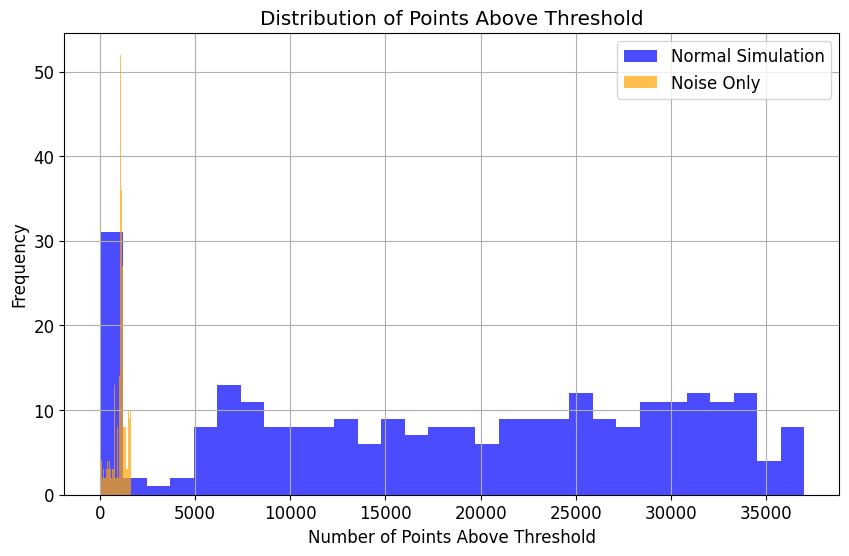

In [172]:
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='blue')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='orange')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2629860/2157237174.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


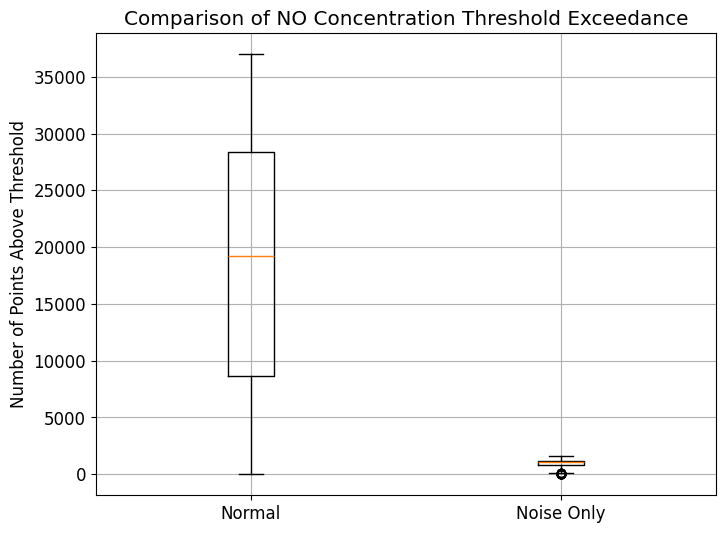

In [173]:
plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance')
plt.grid(True)
plt.show()

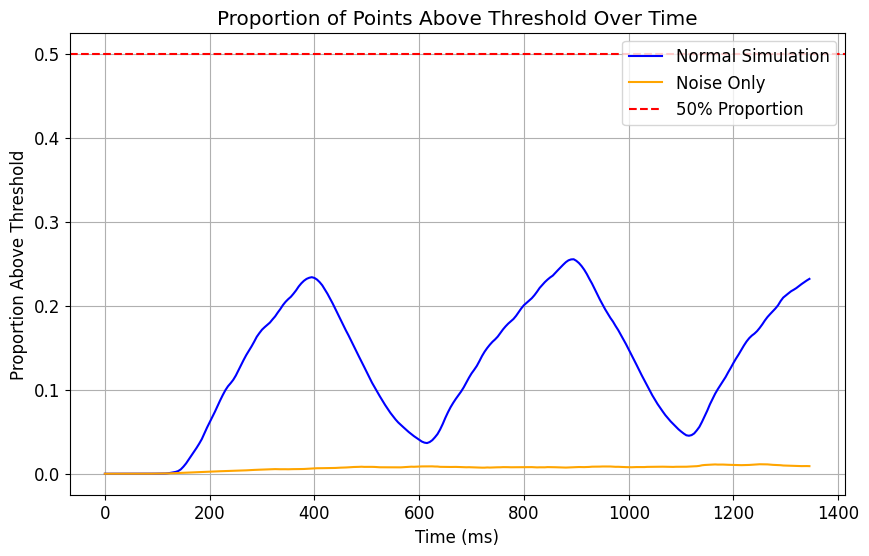

In [174]:
time = np.arange(0, t, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='blue')
plt.plot(time, noise_proportion, label='Noise Only', color='orange')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time')
plt.legend()
plt.grid(True)
plt.show()

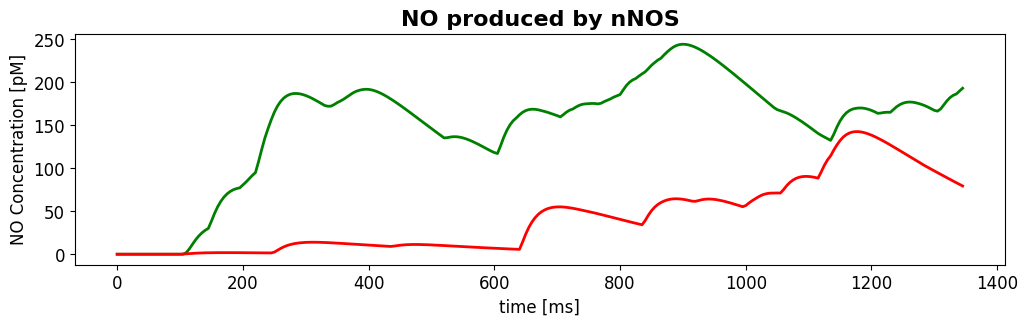

In [175]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(0,t,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(0,t,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

In [176]:
result_path = 'results/NO_concentration_data_CS_5ms_cycled_1/'
concentration_CS_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_CS_clusters.append(concentrations)

In [177]:
concentration_CS_clusters = np.array(concentration_CS_clusters)
max_value_index = np.argmax(concentration_CS_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_CS_clusters.shape)
concentration_plot_CS = concentration_CS_clusters[:,col]
concentration_CS_clusters[row,col]

np.float64(411.5209079040204)

In [178]:
result_path = 'results/NO_concentration_data_noise_5ms_cycled_1/'
concentration_noise_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_noise_clusters.append(concentrations)

In [179]:
concentration_noise_clusters = np.array(concentration_noise_clusters)
max_value_index = np.argmax(concentration_noise_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_noise_clusters[:,col]
concentration_noise_clusters[row,col]

np.float64(216.6092116221987)

In [180]:
threshold = 60
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}


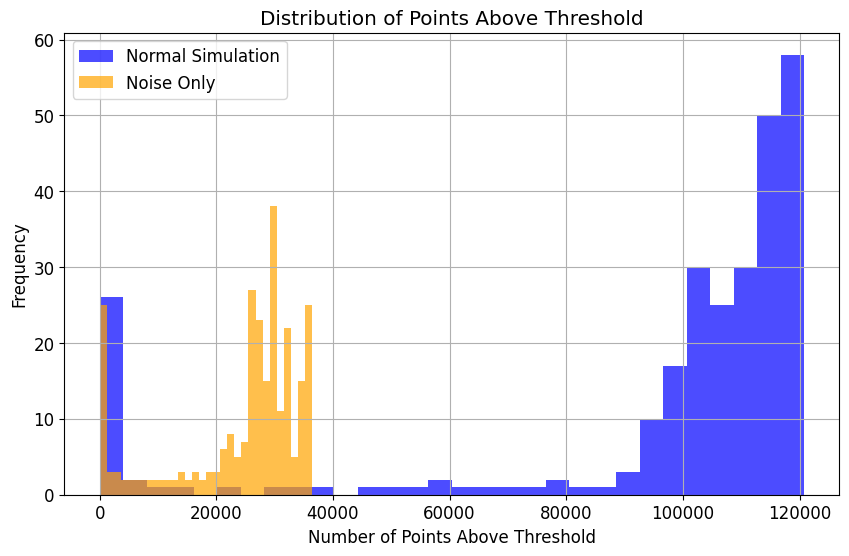

In [181]:
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='blue')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='orange')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_2629860/3191018038.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


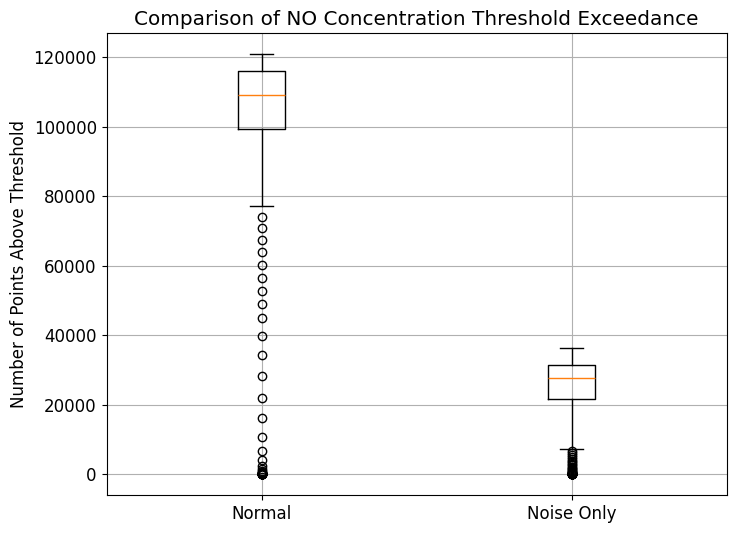

In [182]:

plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance')
plt.grid(True)
plt.show()


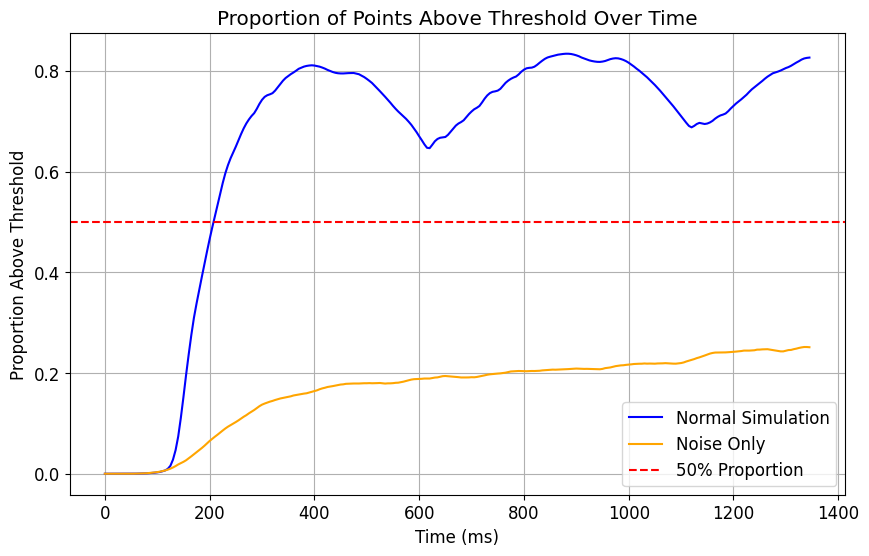

In [183]:

time = np.arange(0, t, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='blue')
plt.plot(time, noise_proportion, label='Noise Only', color='orange')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time')
plt.legend()
plt.grid(True)
plt.show()

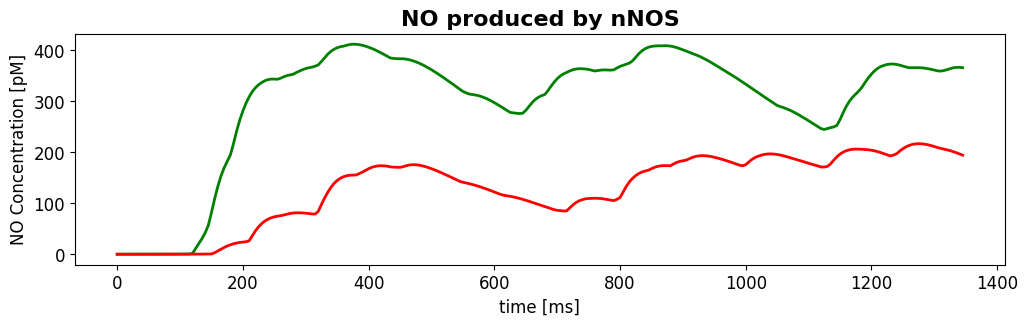

In [184]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(0,t,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(0,t,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

In [ ]:
id = col

concentration_plot = concentration_data_clusters[:,col]

fig = go.Figure(go.Scatter(x=np.arange(0,620,5),y=concentration_plot, name = 'overall',
                          mode = 'lines',
                          line = dict(width= 5, color= 'red')))

fig.update_xaxes(title = 'Time [ms]')
fig.update_yaxes(title = 'NO Concentration [pM]')
fig.update_layout(title_text = 'Concentration at source')

fig.show()

In [ ]:
frames = []
for i in range(100):
    frame = go.Frame(
        data=[
            go.Scatter3d(
                x=ev_points_n_clusters[:, 1],
                y=ev_points_n_clusters[:, 2],
                z=ev_points_n_clusters[:, 3],
                text = ev_points_n_clusters[:,0],
                mode='markers',
                marker=dict(
                    size=3,
                    color=concentration_data_clusters[i],  # Set color to the log-transformed concentrations
                    colorscale='Viridis',  # Color scale
                    cmin=0,  # Set minimum value for the color scale
                    cmax=400,  # Set maximum value for the color scale
                    colorbar=dict(title='Log10 Concentration'),
                    opacity=0.8
                )
            )
        ],
        name=str(i*5)
    )
    frames.append(frame)

# Create the initial figure
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=ev_points_n_clusters[:, 1],
            y=ev_points_n_clusters[:, 2],
            z=ev_points_n_clusters[:, 3],
            text = ev_points_n_clusters[:,0],
            mode='markers',
            marker=dict(
                size=3,
                color=np.zeros(len(ev_points_n_clusters)),  # Default color (zeros)
                colorscale='Viridis',
                cmin=0,  # Set minimum value for the color scale
                cmax=400,  # Set maximum value for the color scale
                colorbar=dict(title='Log10 Concentration'),
                opacity=0.8
            )
        )
    ],
    layout=go.Layout(
        updatemenus=[
            {
                'buttons': [
                    {
                        'args': [None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}],
                        'label': 'Play',
                        'method': 'animate'
                    },
                    {
                        'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                        'label': 'Pause',
                        'method': 'animate'
                    }
                ],
                'direction': 'left',
                'pad': {'r': 10, 't': 87},
                'showactive': True,
                'type': 'buttons',
                'x': 0.1,
                'xanchor': 'right',
                'y': 0,
                'yanchor': 'top'
            }
        ],
        sliders=[{
            'active': 0,
            'steps': [
                {
                    'label': str(i),
                    'method': 'animate',
                    'args': [
                        [str(i)],
                        {'mode': 'immediate', 'transition': {'duration': 300}}
                    ]
                }
                for i in range(0,500,5)
            ]
        }]
    )
)

# Add the frames to the figure
fig.frames = frames

#fig.write_html('3dplot_NO_diffusion.html')

# Show the figure
fig.show()

In [25]:
result_path = 'results/NO_concentration_data_testdiff/'

In [26]:
concentration_data_noise =[]
for i in range(0,500,2):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path)
    matched_conc = df_conc[df_conc.iloc[:, 0].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 1].values
    concentration_data_noise.append(concentrations)

In [27]:
concentration_data_noise = np.array(concentration_data_noise)
max_value_index = np.argmax(concentration_data_noise)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_data_noise.shape)

In [ ]:
id = col

concentration_data_noise_np = np.array(concentration_data_noise)
concentration_plot = concentration_data_noise_np[:,col]

fig = go.Figure(go.Scatter(x = np.arange(0,500,2),y=concentration_plot, name = 'overall',
                          mode = 'lines',
                          line = dict(width= 5, color= 'red')))

fig.update_xaxes(title = 'Time [ms]')
fig.update_yaxes(title = 'NO Concentration [pM]')
fig.update_layout(title_text = 'Concentration at receiver')

fig.show()

In [153]:
result_path_1 = 'results/NO_concentration_data_2/'
concentration_data_clusters_1 =[]
conc_max = 4_000_000
for i in range(500):
    file_path = result_path_1 + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path)
    matched_conc = df_conc[df_conc.iloc[:, 0].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 1].values
    concentration_data_clusters_1.append(concentrations)

In [ ]:
concentration_data_clusters_np_1 = np.array(concentration_data_clusters_1)
concentration_plot = concentration_data_clusters_np_1[:,3801]

fig = go.Figure(go.Scatter(y=concentration_plot, name = 'overall',
                          mode = 'lines',
                          line = dict(width= 5, color= 'red')))

fig.update_xaxes(title = 'Time [ms]')
fig.update_yaxes(title = 'NO Concentration [pM]')
fig.update_layout(title_text = 'Concentration at receiver')

fig.show()

In [ ]:
ev_points_id = ev_points['ev_points_id'].values
r_max = 15
nNOS_ev_points = []
for id_cluster in cluster:
            # loop on the receiver
            for evpoint_id in ev_points_id:
                df_row = ev_points.loc[evpoint_id+1]
                # loop on the sources
                if df_row['cluster']==id_cluster:
                    ev_point_coordinates = np.array([df_row['x'],df_row['y'],df_row['z']])
                    nNOS = []
                    for evpoint_id_1 in ev_points_id:
                        df_row_1 =  ev_points.loc[evpoint_id_1+1]
                        if df_row_1['cluster']==id_cluster:
                            nNOS_coordinates = np.array([df_row_1['x'],df_row_1['y'],df_row_1['z']])                   
                            # distance evaluation
                            d = spatial.distance.euclidean(nNOS_coordinates, ev_point_coordinates)
                            # check on relevant distance value
                            if d < r_max:
                                # lists update
                                nNOS.append(df_row_1['ev_points_id'])
                    nNOS_ev_points.append(nNOS)

In [ ]:
np.mean([len(nNOS_ev_points[i]) for i in range(len(nNOS_ev_points))])

In [16]:
result_path_noise = 'results/NO_concentration_data_noise/'
concentration_data_noise =[]
epsilon = 1e-10
conc_max = 4_000_000
for i in range(500):
    file_path = result_path_noise + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path)
    matched_conc = df_conc[df_conc.iloc[:, 0].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 1].values
    log_concentrations_noise = np.log10(concentrations + epsilon)
    concentration_data_noise.append(log_concentrations_noise)

In [ ]:
frames = []
for i in range(500):
    frame = go.Frame(
        data=[
            go.Scatter3d(
                x=ev_points_n_clusters[:, 1],
                y=ev_points_n_clusters[:, 2],
                z=ev_points_n_clusters[:, 3],
                text = ev_points_n_clusters[:,0],
                mode='markers',
                marker=dict(
                    size=3,
                    color=concentration_data_noise[i],  # Set color to the log-transformed concentrations
                    colorscale='Viridis',  # Color scale
                    cmin=0,  # Set minimum value for the color scale
                    cmax=np.log10(conc_max + epsilon),  # Set maximum value for the color scale
                    colorbar=dict(title='Log10 Concentration'),
                    opacity=0.8
                )
            )
        ],
        name=str(i)
    )
    frames.append(frame)

# Create the initial figure
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=ev_points_n_clusters[:, 1],
            y=ev_points_n_clusters[:, 2],
            z=ev_points_n_clusters[:, 3],
            text = ev_points_n_clusters[:,0],
            mode='markers',
            marker=dict(
                size=3,
                color=np.zeros(len(ev_points_n_clusters)),  # Default color (zeros)
                colorscale='Viridis',
                cmin=0,  # Set minimum value for the color scale
                cmax=np.log10(conc_max + epsilon),  # Set maximum value for the color scale
                colorbar=dict(title='Log10 Concentration'),
                opacity=0.8
            )
        )
    ],
    layout=go.Layout(
        updatemenus=[
            {
                'buttons': [
                    {
                        'args': [None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}],
                        'label': 'Play',
                        'method': 'animate'
                    },
                    {
                        'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                        'label': 'Pause',
                        'method': 'animate'
                    }
                ],
                'direction': 'left',
                'pad': {'r': 10, 't': 87},
                'showactive': True,
                'type': 'buttons',
                'x': 0.1,
                'xanchor': 'right',
                'y': 0,
                'yanchor': 'top'
            }
        ],
        sliders=[{
            'active': 0,
            'steps': [
                {
                    'label': str(i),
                    'method': 'animate',
                    'args': [
                        [str(i)],
                        {'mode': 'immediate', 'transition': {'duration': 300}}
                    ]
                }
                for i in range(500)
            ]
        }]
    )
)

# Add the frames to the figure
fig.frames = frames

fig.write_html('3dplot_NO_diffusion_noise.html')

# Show the figure
fig.show()

In [18]:

concentration_data_noise_1 =[]
conc_max = 4_000_000
for i in range(500):
    file_path = result_path_noise + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path)
    matched_conc = df_conc[df_conc.iloc[:, 0].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 1].values
    concentration_data_noise_1.append(concentrations)
concentration_data_noise_np = np.array(concentration_data_noise_1)

In [19]:
max_value_index = np.argmax(concentration_data_noise_np)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_data_noise_np.shape)

In [ ]:
col

In [ ]:
id = 1501

concentration_plot = concentration_data_noise_np[:,id]

fig = go.Figure(go.Scatter(y=concentration_plot, name = 'overall',
                          mode = 'lines',
                          line = dict(width= 5, color= 'red')))

fig.update_xaxes(title = 'Time [ms]')
fig.update_yaxes(title = 'NO Concentration [pM]')
fig.update_layout(title_text = 'Concentration at receiver')

fig.show()

In [ ]:
ev_points.iloc[:,0].values[1501]

In [36]:
result_path = 'results/NO_concentration_data_test_rec_1/'

In [48]:
concentration = []
concentration_data =[]
i = 150
#for i in range(0,500,2):
file_path = result_path + f'NO_concentration_t_{i}.csv'
df_conc = pd.read_csv(file_path)
ev_points_id = np.unique(df_conc.iloc[:,1].values)
for id in ev_points_id:
    matched_ev_point = df_conc[df_conc.iloc[:, 1].isin([id])]
    concentration.append(np.sum(matched_ev_point.iloc[:, 2].values))
concentration = np.array(concentration)
concentration_data.append(concentration)
    #concentration_data.append(concentrations)
#concentration_data_np = np.array(concentration_data)

In [ ]:
concentration_plot = concentration_data_np

fig = go.Figure(go.Scatter(x = np.arange(0,500,2),y=concentration_plot, name = 'overall',
                          mode = 'lines',
                          line = dict(width= 5, color= 'red')))

fig.update_xaxes(title = 'Time [ms]')
fig.update_yaxes(title = 'NO Concentration [pM]')
fig.update_layout(title_text = 'Concentration at source')

fig.show()